# Exploratory Data Analysis (EDA)
This notebook performs Exploratory Data Analysis on two real-world datasets:
1. **Titanic Survival Data**: Focus on missing data and multivariate analysis.
2. **LendingClub Loan Data**: Focus on loan status, interest rates, and grade distributions.

Datasets are imported from [OpenML.org](https://OpenML.org), a public repository for machine learning data.
sklearn has multiple datasets which can be loaded from scikitlearn.datasets

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 1. Load Titanic Dataset from OpenML
print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML
print('Fetching LendingClub dataset from OpenML...')
# Using a common OpenML version of lending club
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


## 1. Titanic
Get a sample of the data

In [16]:
titanic_df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 1.1 Titanic: Summary Statistics & Distributions
We look at both numerical and categorical features to understand the passenger data.

,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


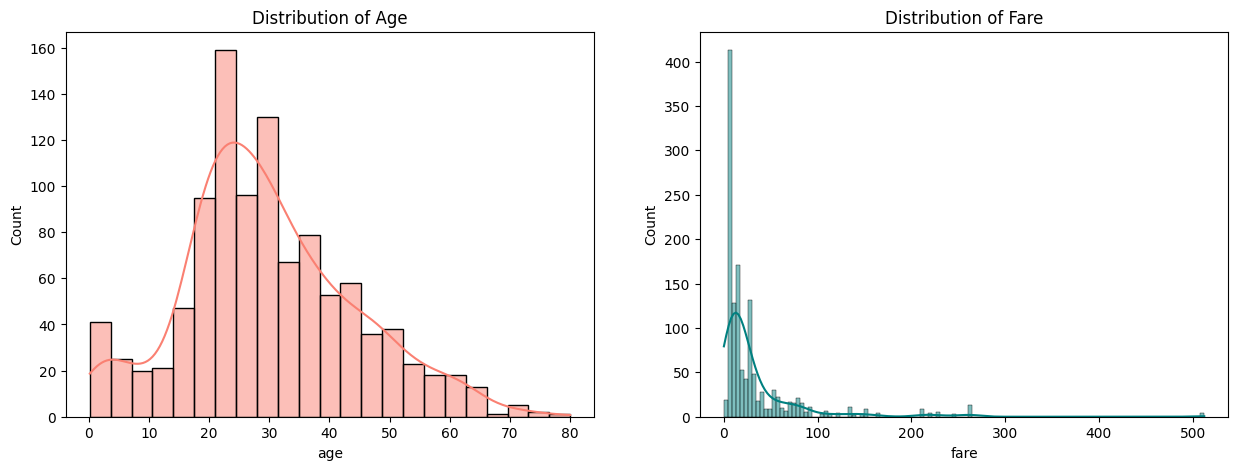

In [25]:
# Summary statistics for numeric columns
display(titanic_df.describe())

# Distribution of Age and Fare
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(titanic_df['age'].dropna(), kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Age')

sns.histplot(titanic_df['fare'].dropna(), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Fare')

plt.show()

In [31]:
# Missing values for all variables in Titanic dataset
print("--- Titanic Missing Values ---")
print(titanic_df.isnull().sum())


--- Titanic Missing Values ---
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


In [42]:
# Value counts for specific categorical columns using Top 5 logic for all
target_cols = ['survived', 'sex', 'embarked', 'home.dest','pclass']

for col in target_cols:
    print(f"--- Analysis for {col} ---")
    counts = titanic_df[col].value_counts(dropna=True, normalize=True)

    if len(counts) > 5:
        top_5 = counts.nlargest(5)
        others_count = counts.iloc[5:].sum()
        res = pd.concat([top_5, pd.Series({'Others': others_count})])
        print("Top Counts:")
        print(res)
    else:
        print("Counts:")
        print(counts)
    print("\n")

--- Analysis for survived ---
Counts:
survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64


--- Analysis for sex ---
Counts:
sex
male      0.644003
female    0.355997
Name: proportion, dtype: float64


--- Analysis for embarked ---
Counts:
embarked
S    0.699311
C    0.206580
Q    0.094109
Name: proportion, dtype: float64


--- Analysis for home.dest ---
Top Counts:
New York, NY            0.085906
London                  0.018792
Montreal, PQ            0.013423
Cornwall / Akron, OH    0.012081
Paris, France           0.012081
Others                  0.857718
dtype: float64


--- Analysis for pclass ---
Counts:
pclass
3    0.541635
1    0.246753
2    0.211612
Name: proportion, dtype: float64




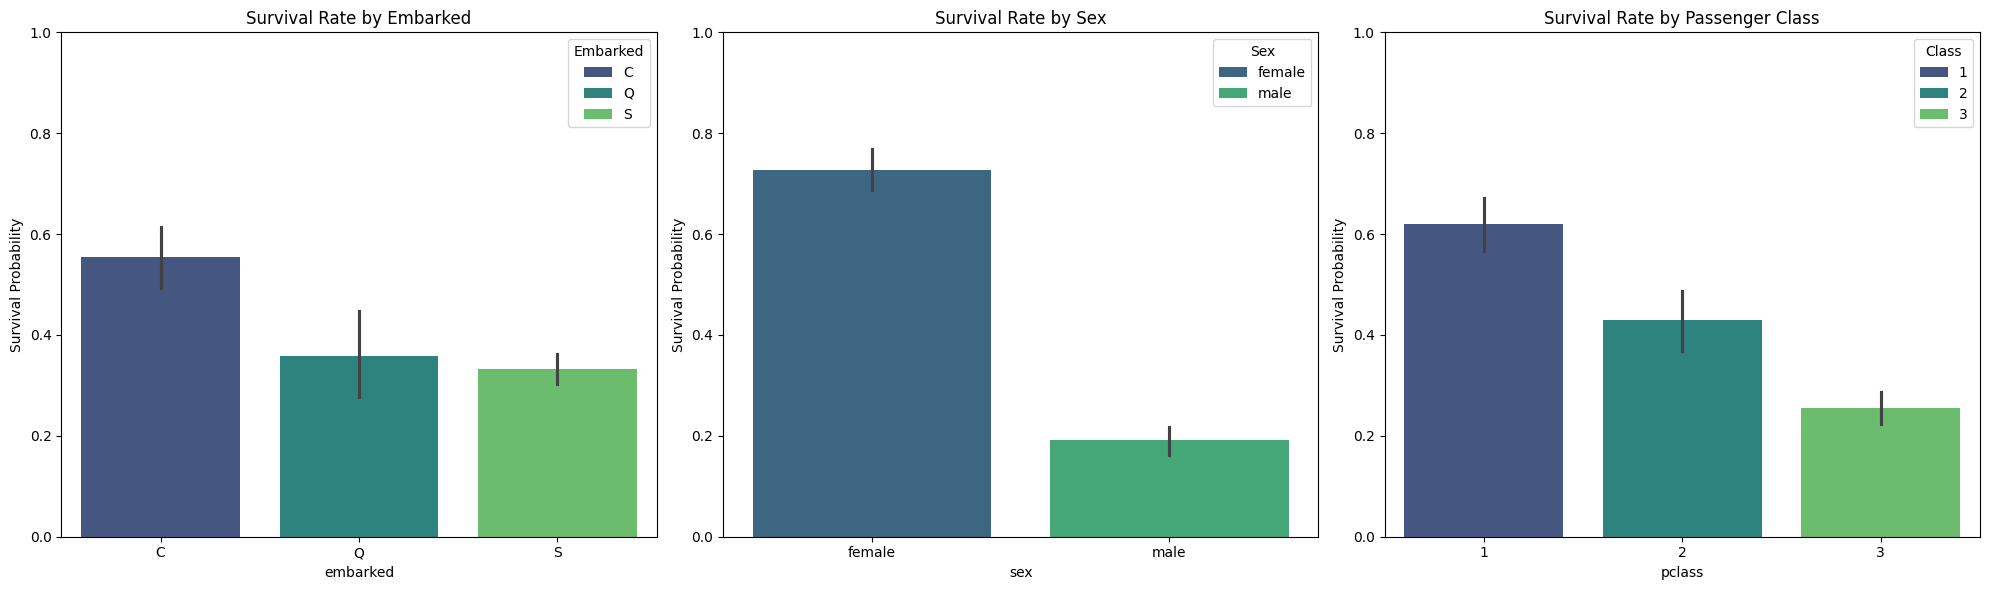

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure pclass is categorical (string)
titanic_df['pclass'] = titanic_df['pclass'].astype(str)

# Standardizing palette and layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Survival Rate by Embarked
sns.barplot(data=titanic_df, x='embarked', y='survived', ax=axes[0], palette='viridis', hue='embarked', legend='brief')
axes[0].set_title('Survival Rate by Embarked')
axes[0].set_ylabel('Survival Probability')
axes[0].set_ylim(0, 1)
axes[0].legend(title='Embarked', loc='upper right')

# 2. Survival Rate by Sex
sns.barplot(data=titanic_df, x='sex', y='survived', ax=axes[1], palette='viridis', hue='sex', legend='brief')
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Probability')
axes[1].set_ylim(0, 1)
axes[1].legend(title='Sex', loc='upper right')

# 3. Survival Rate by Pclass (Categorical)
sns.barplot(data=titanic_df, x='pclass', y='survived', ax=axes[2], palette='viridis', hue='pclass', legend='brief', order=['1', '2', '3'])
axes[2].set_title('Survival Rate by Passenger Class')
axes[2].set_ylabel('Survival Probability')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Class', loc='upper right')

plt.tight_layout()
plt.show()

## 1.2 Titanic: Correlations
We check for relationships between numeric variables such as `pclass`, `age`, `sibsp`, `parch`, and the target `survived`.

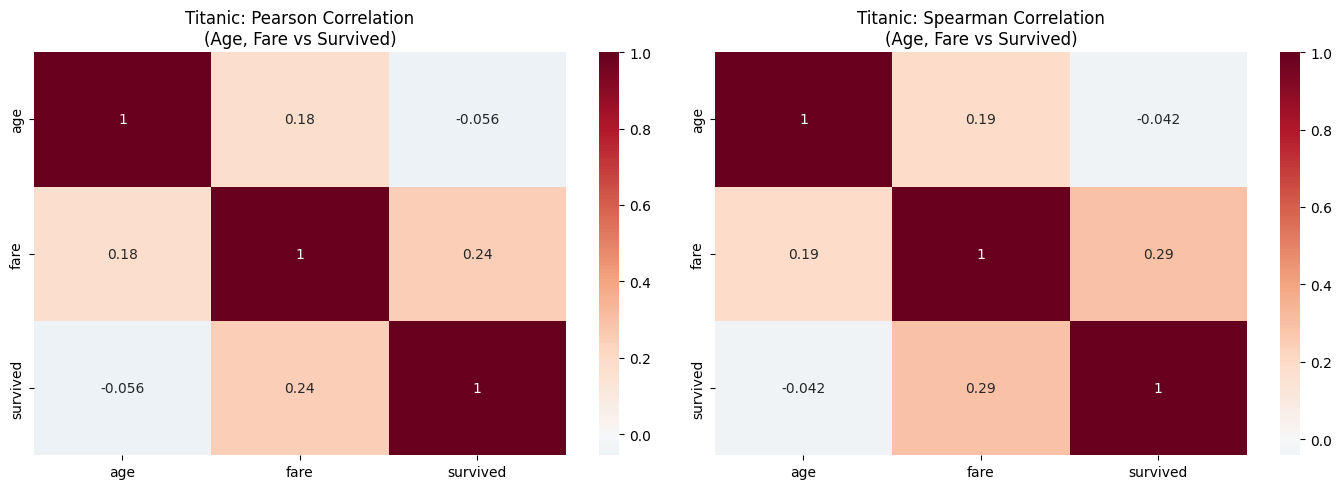

In [39]:
# Select numeric columns and ensure target is included
titanic_df['survived'] = pd.to_numeric(titanic_df['survived'])
titanic_numeric = titanic_df[['age', 'fare', 'survived']]

# Calculate correlations
corr_p = titanic_numeric.corr(method='pearson')
corr_s = titanic_numeric.corr(method='spearman')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_p, annot=True, cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Titanic: Pearson Correlation\n(Age, Fare vs Survived)')

sns.heatmap(corr_s, annot=True, cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Titanic: Spearman Correlation\n(Age, Fare vs Survived)')

plt.tight_layout()
plt.show()


# Observations
**Passanger profile**

*   Male: 64%, Female: 36%
*   Class 3 was the biggest class with 54% passangers
*   70% of the passangers boarded in Southampton
*   Median age was 30 and the distribution is close to normal
*   Fare distribution is extremely skewed and requires log transformation



**Survival**
*   500 survived of total 1309 passangers. Survival rate depended on sex and passanger class, with females and first class passangers more likely to survive.
*   Interestingly the correlation of survival with age is lower. But fare has higher correlation with survival, which must be correlated with the Passanger class. Both Pearson and Spearman coefficients indicate to similar trend.

**Missing Data**
*   A value is "missing" (null) for approximately 90% of the passengers because their bodies were either never recovered or they survived.
*   Other features with missing data are cabin and boat. Since boat variable would be present for all survived passangers (assuming survived used lifeboats), this should not be used for prediction as it is leaky variable.
*   Missing data for age could be because of recording bias. It could be imputed.
*   Missing data for Home destination is higher for lower classes. So this is Missing Not at Random (MNAR)



## 2. LendingClub: Distributions & Loan Status
We analyze the distribution of interest rates and the loan status counts.

In [53]:
lending_df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [54]:
lending_df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


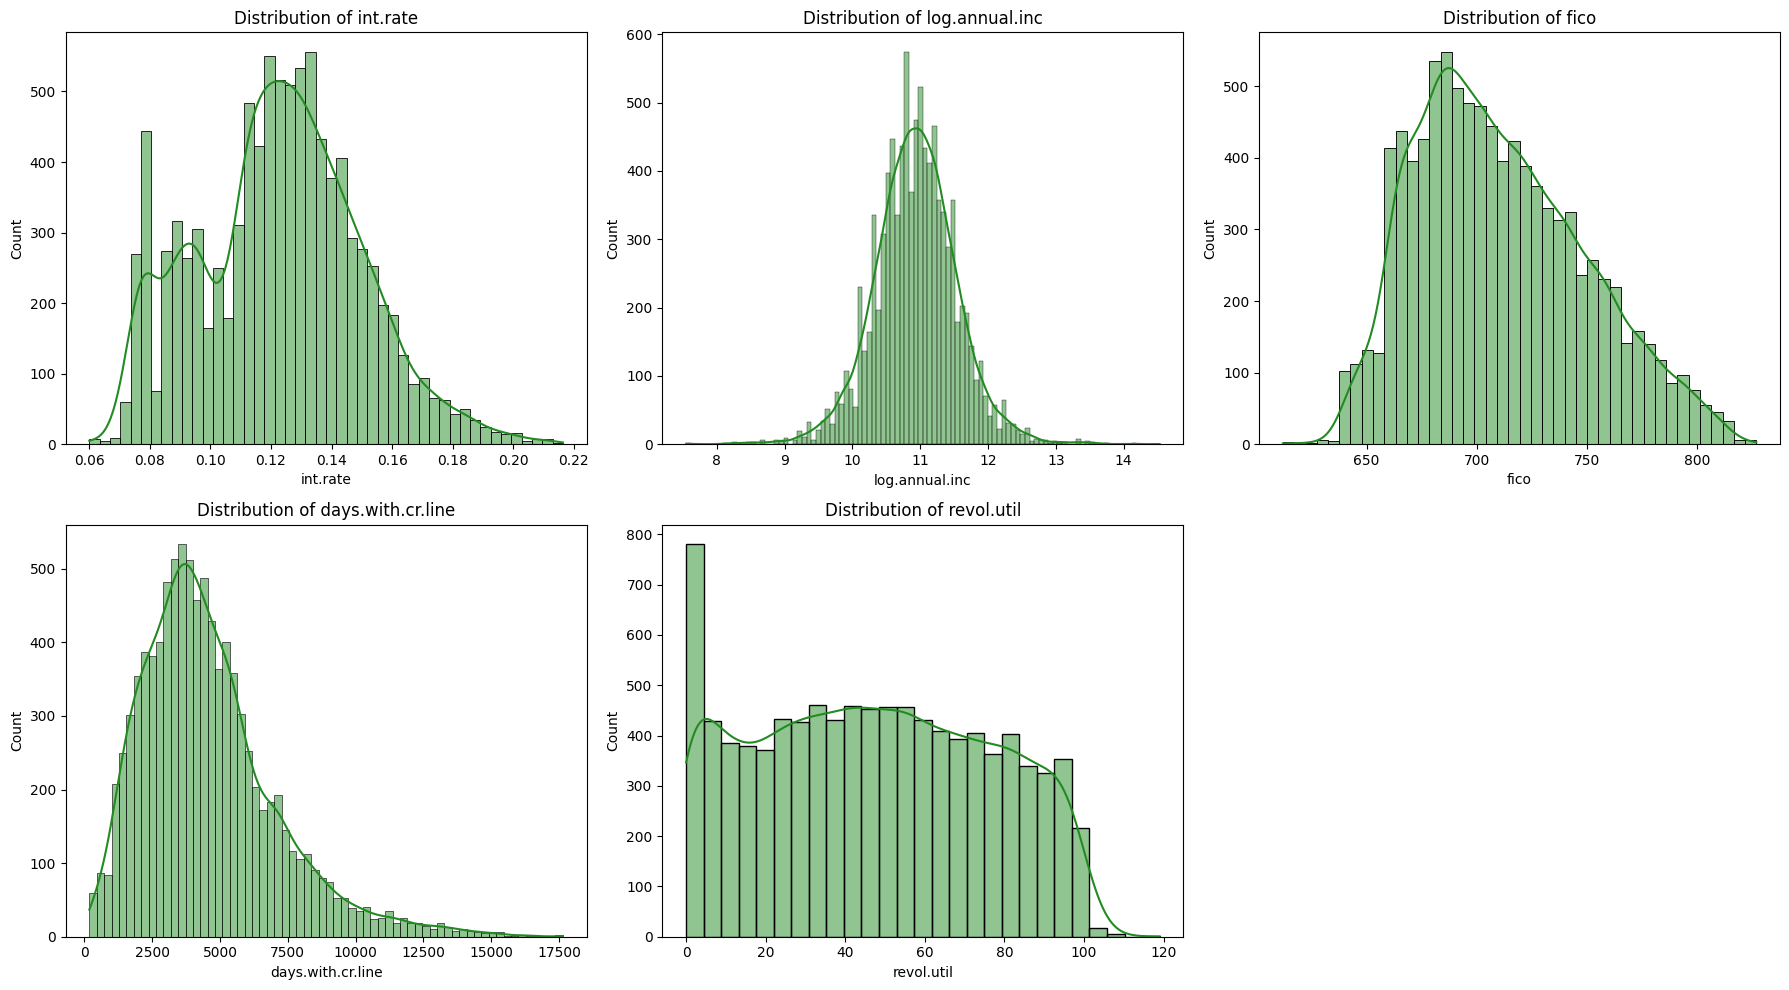

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to visualize
cols_to_plot = ['int.rate', 'log.annual.inc', 'fico', 'days.with.cr.line', 'revol.util']

# Create a grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(lending_df[col], kde=True, ax=axes[i], color='forestgreen')
    axes[i].set_title(f'Distribution of {col}')

# Hide the unused last subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [56]:
# Value counts for categorical columns in LendingClub
cat_cols = ['credit.policy', 'purpose', 'not.fully.paid']

for col in cat_cols:
    print(f"--- Analysis for {col} ---")
    counts = lending_df[col].value_counts(dropna=True, normalize=True)

    if len(counts) > 5:
        top_5 = counts.nlargest(5)
        others_count = counts.iloc[5:].sum()
        res = pd.concat([top_5, pd.Series({'Others': others_count})])
        print("Top Counts (Normalized):")
        print(res)
    else:
        print("Counts (Normalized):")
        print(counts)
    print("\n")

--- Analysis for credit.policy ---
Counts (Normalized):
credit.policy
1    0.80497
0    0.19503
Name: proportion, dtype: float64


--- Analysis for purpose ---
Top Counts (Normalized):
debt_consolidation    0.413134
all_other             0.243370
credit_card           0.131760
home_improvement      0.065671
small_business        0.064627
Others                0.081437
dtype: float64


--- Analysis for not.fully.paid ---
Counts (Normalized):
not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64




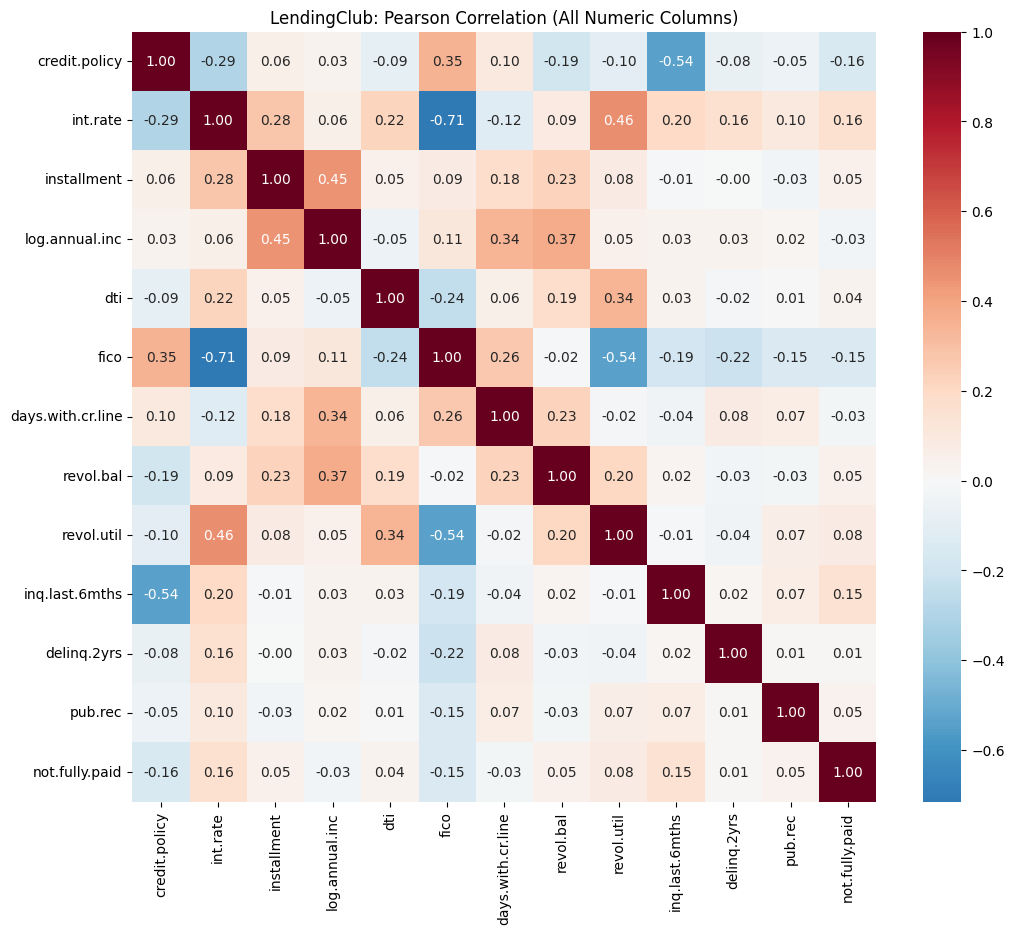

In [57]:
# Selecting all numerical columns for correlation in LendingClub
lending_numeric = lending_df.select_dtypes(include=[np.number])

corr_p = lending_numeric.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_p, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('LendingClub: Pearson Correlation (All Numeric Columns)')
plt.show()

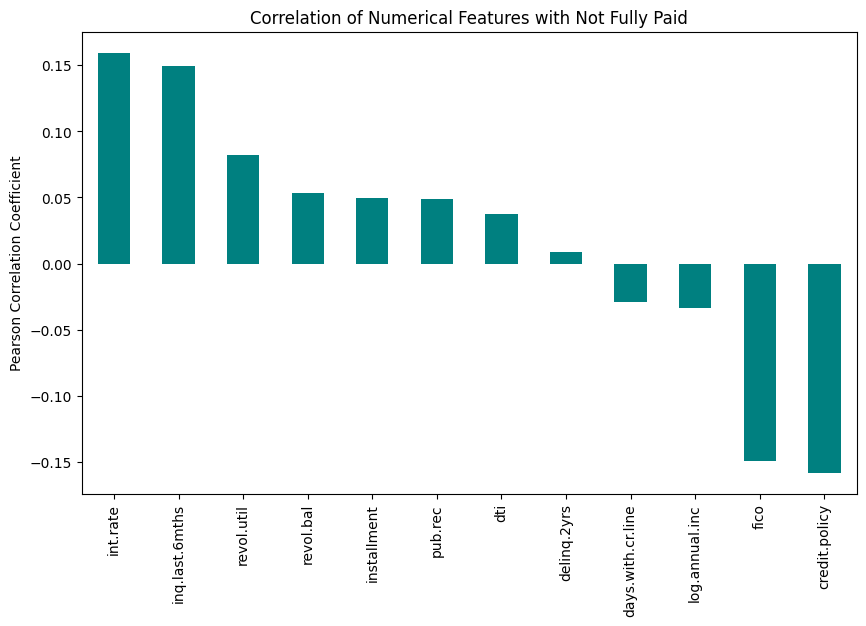

Correlations with target (not.fully.paid):
not.fully.paid       1.000000
int.rate             0.159552
inq.last.6mths       0.149452
revol.util           0.082088
revol.bal            0.053699
installment          0.049955
pub.rec              0.048634
dti                  0.037362
delinq.2yrs          0.008881
days.with.cr.line   -0.029237
log.annual.inc      -0.033439
fico                -0.149666
credit.policy       -0.158119
Name: not.fully.paid, dtype: float64


In [58]:
# Correlation of target variable 'not.fully.paid' with other numerical variables
target_corr = lending_numeric.corr()['not.fully.paid'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr.drop('not.fully.paid').plot(kind='bar', color='teal')
plt.title('Correlation of Numerical Features with Not Fully Paid')
plt.ylabel('Pearson Correlation Coefficient')
plt.show()

print("Correlations with target (not.fully.paid):")
print(target_corr)

# Observations: LendingClub

**Loan Profile**
* **Interest Rates**: Typically range from 5% to 25%, showing a multi-modal distribution.
* **Correlations**: Strong positive correlation between `loan_amnt` and `installment`, as expected.
* **Status**: The majority of loans are 'Current' or 'Fully Paid', but there is a notable portion of 'Charged Off' or 'Late' loans.

### Detailed Observations: LendingClub

**Loan & Borrower Profile**
* **Risk Pricing**: Interest rates show a strong multi-modal distribution, heavily influenced by credit scores. Borrowers with higher FICO scores consistently receive lower interest rates (correlation ~ -0.71).
* **Debt Consolidation**: This is the primary driver for loans (over 41%), followed by credit card refinancing. Small business loans, while less frequent, often represent higher individual risk profiles.
* **Financial Health**: There is a clear relationship between credit utilization (`revol.util`) and FICO scores, where high utilization negatively impacts the borrower's credit rating.

**Correlation with Defaults (`not.fully.paid`)**
* **Primary Predictors**: The strongest indicators of a loan not being fully paid are higher **interest rates** and a higher number of **recent credit inquiries**. This suggests that borrowers seeking credit frequently or those assigned high-risk rates are more likely to default.
* **Protective Factors**: Meeting the internal **credit policy** and having a high **FICO score** are the strongest negative correlates with default, validating the underwriting process.
* **Weak Correlations**: Interestingly, variables like `delinq.2yrs` (past delinquencies) and `days.with.cr.line` show very weak direct correlations with the target compared to real-time credit metrics.

**Data Quality & Imbalance**
* **Class Imbalance**: The dataset is imbalanced, with only ~16% of loans not being fully paid. Any future predictive modeling will need to account for this to avoid bias toward the majority 'paid' class.
* **Completeness**: Unlike the Titanic dataset, the LendingClub data from OpenML is highly structured with very few missing values in the numerical features, making it suitable for direct correlation analysis.